# 01. Data Exploration

Первичная проверка качества данных, распределений и базовых метрик продукта.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('../data')

In [2]:
users = pd.read_csv(DATA_DIR / 'dim_users.csv', parse_dates=['registration_ts'])
orders = pd.read_csv(DATA_DIR / 'fact_orders.csv', parse_dates=['order_ts'])
sessions = pd.read_csv(DATA_DIR / 'fact_app_sessions.csv', parse_dates=['session_start_ts', 'session_end_ts'])

users.head(), orders.head(), sessions.head()

(   user_id               registration_ts acquisition_channel           city  \
 0    10218 2025-01-01 00:07:45.345171840          social_ads         Moscow   
 1    12491 2025-01-01 01:13:33.897248738             organic         Moscow   
 2    13202 2025-01-01 01:56:30.053857155            referral         Moscow   
 3     5482 2025-01-01 03:05:10.835614890             organic  Yekaterinburg   
 4     6120 2025-01-01 04:05:32.842755125             organic         Moscow   
 
   device_os  age  gender loyalty_tier  
 0   Android   37  female         gold  
 1   Android   60    male          new  
 2       iOS   24    male       silver  
 3   Android   31  female       silver  
 4   Android   26    male          new  ,
    order_id  user_id  restaurant_id  courier_id  campaign_id  \
 0         6     5482            158          67          1.0   
 1        22     2880            240         124          1.0   
 2        53     8299            108          20          NaN   
 3        4

In [3]:
print('Users:', len(users))
print('Orders:', len(orders))
print('Sessions:', len(sessions))
print('Delivered share:', (orders['order_status'] == 'delivered').mean().round(4))

Users: 14000
Orders: 21976
Sessions: 94745
Delivered share: 0.9487


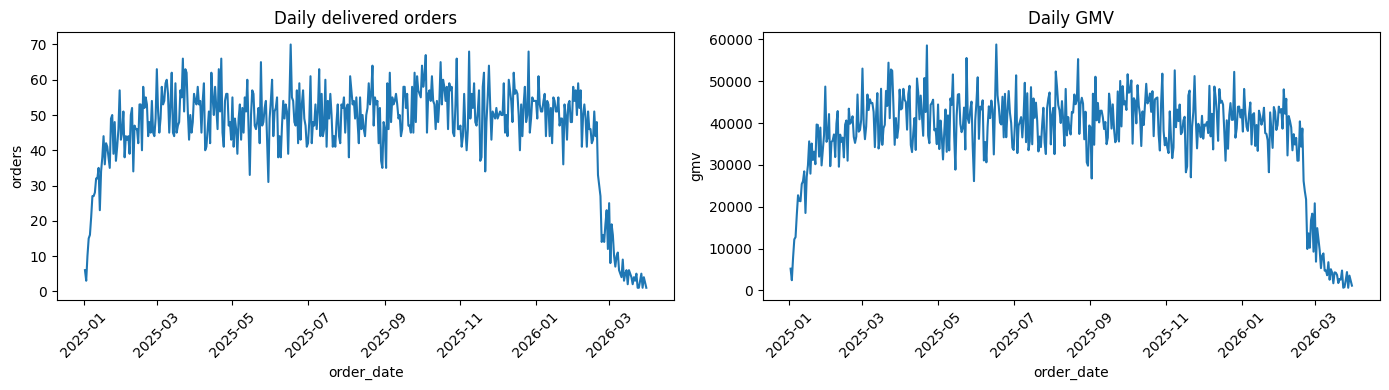

In [4]:
orders['order_date'] = orders['order_ts'].dt.normalize()
orders['gmv_rub'] = orders['basket_value_rub'] + orders['delivery_fee_rub'] - orders['discount_rub']
daily = orders[orders['order_status'] == 'delivered'].groupby('order_date').agg(
    orders=('order_id', 'count'),
    gmv=('gmv_rub', 'sum')
).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=daily, x='order_date', y='orders', ax=ax[0])
ax[0].set_title('Daily delivered orders')
sns.lineplot(data=daily, x='order_date', y='gmv', ax=ax[1])
ax[1].set_title('Daily GMV')
for a in ax:
    a.tick_params(axis='x', rotation=45)
plt.tight_layout()
